# RAG
<div style="display: flex; justify-content: center; align-items: center;padding-top:1%">
    <img src="images/Overview.png" width="50%" height="50%">
</div>

### 🔍 Advanced Query Translation Techniques for RAG

Le **Query Translation** (ou reformulation de requête) regroupe un ensemble de techniques visant à transformer la question initiale d'un utilisateur avant la phase de récupération (*retrieval*). Ces approches permettent d'optimiser les recherches dans les bases de données vectorielles et d'assurer l'extraction des documents les plus pertinents pour le RAG (*Retrieval-Augmented Generation*).

---

#### 1. Multi-Query
* **Principe :** Résoudre les limitations liées au choix des mots de l'utilisateur en générant plusieurs variantes de la même question.
* **Fonctionnement :**
  1. Un LLM génère $N$ reformulations (ex: 4) à partir de la requête initiale.
  2. Chaque variante effectue une recherche vectorielle distincte.
  3. Seuls les documents figurant dans l'intersection des résultats sont retenus pour la réponse finale.

---

#### 2. RAG Fusion
* **Principe :** Étendre l'approche *Multi-Query* en appliquant un système de réordonnancement (*re-ranking*) intelligent.
* **Fonctionnement :**
  1. Génération de plusieurs variantes de la requête initiale via un LLM.
  2. Exécution de recherches vectorielles pour toutes les requêtes.
  3. Fusion de tous les documents extraits et classement du plus important au moins important à l'aide d'un algorithme dédié (ex: **Reciprocal Rank Fusion - RRF**).

---

#### 3. Decomposition (Sub-querying)
* **Principe :** Découper une requête complexe ou multi-étapes en une série de sous-questions simples et ordonnées.
* **Fonctionnement :**
  1. La question initiale est décomposée en $N$ sous-questions.
  2. La **sous-question 1** est envoyée à la base vectorielle pour obtenir une première réponse.
  3. Le couple *(sous-question 1 + sa réponse)* est utilisé comme contexte enrichi pour exécuter la **sous-question 2**.
  4. Le processus itère jusqu'à l'obtention du résultat final.

---

#### 4. Step-Back Prompting
* **Principe :** Générer une question plus globale et abstraite pour extraire les concepts de haut niveau entourant le sujet.
* **Fonctionnement :**
  1. Génération d'une question "step-back" (plus générale / théorique).
  2. Récupération des documents pour la question *step-back* **ET** pour la question spécifique initiale.
  3. Fourniture au LLM d'un contexte hybride combinant les faits précis et le cadrage conceptuel.

---

#### 5. HyDE (Hypothetical Document Embeddings)
* **Principe :** Résoudre l'asymétrie sémantique entre une question courte et des *chunks* de documents longs.
* **Fonctionnement :**
  1. Le LLM génère un "document hypothétique" (une hallucination contrôlée) répondant directement à la question.
  2. On vectorise ce document hypothétique au lieu de la question brute.
  3. La recherche vectorielle s'effectue de document à document, maximisant ainsi la similarité sémantique.

---

#### 📊 Tableau Récapitulatif

| Technique | Objectif Principal | Type de Recherche | Cas d'Usage Idéal |
| :--- | :--- | :--- | :--- |
| **Multi-Query** | Couvrir les synonymes et expressions | Vectorielle multiple (Intersection) | Questions simples avec risque d'ambiguïté lexicale |
| **RAG Fusion** | Prioriser et pondérer la pertinence | Vectorielle + Re-ranking (RRF) | Requêtes larges nécessitant un fort niveau de précision |
| **Decomposition** | Traiter les questions complexes multi-étapes | Séquentielle / Chînée | Questions comparatives ou processus à étapes |
| **Step-Back** | Apporter du contexte théorique/général | Paralèlle (Spécifique + Abstrait) | Questions nécessitant des principes fondamentaux |
| **HyDE** | Aligner la forme requête / document | Document-à-Document | Questions très courtes ou abstraites |

### 🧠 Routing (Acheminement de requêtes)

Le **Routing** consiste à diriger la question de l'utilisateur vers la ressource la plus adaptée (base de données spécifique, index vectoriel dédié, outil ou sous-chaîne de traitement) afin d'optimiser la pertinence de la réponse.

---

#### 1. Logical Routing (Acheminement logique)
* **Principe :** S'appuyer sur la capacité de raisonnement du LLM pour déterminer la destination.
* **Fonctionnement :** On fournit au LLM la liste des outils ou bases disponibles (via du *Function Calling* / *Tool Use* ou du *Structured Output*). Le modèle analyse la question, sélectionne l'outil adéquat et argumente son choix.

---

#### 2. Semantic Routing (Acheminement sémantique)
* **Principe :** Déterminer la route basée sur la similarité vectorielle sans repasser par une inférence LLM complète (plus rapide et économique).
* **Fonctionnement :** 
  1. On génère les *embeddings* de la question de l'utilisateur.
  2. On les compare aux *embeddings* préalablement calculés des descriptions de chaque route (ou à des exemples de questions types associées à ces routes).
  3. La route sélectionnée est celle qui présente la plus forte corrélation sémantique (mesurée par exemple via la similarité cosinus).

### 🏗️ Query Construction (Construction de requêtes structurées)

La **Query Construction** consiste à transformer une question utilisateur formulée en langage naturel (souvent ambiguë ou informelle) en une requête de base de données structurée (SQL, Cypher, filtres de métadonnées vectorielles, etc.).

---

#### 1. Définition du schéma structuré (*Structured Schema*)
* **Principe :** Définir un schéma de données strict (par exemple via Pydantic ou JSON Schema) qui modélise les paramètres attendus pour interroger la base cible.
* **Fonctionnement :** On contraint la sortie du modèle (*Structured Output*) afin qu'il génère un objet JSON valide contenant les filtres, termes de recherche et opérateurs requis par la base de données.

---

#### 2. Conversion par le LLM
* **Principe :** Consigner dans le *prompt* les règles de correspondance pour guider le modèle dans sa conversion.
* **Fonctionnement :** 
  1. On fournit au LLM la question initiale, le schéma structuré cible ainsi qu'un résumé des données/métadonnées disponibles dans la base.
  2. Le modèle traduit l'intention de la question utilisateur en complétant le schéma JSON.
  3. L'application extrait le JSON validé et l'exécute directement auprès de la base de données cible (RDBMS, base vectorielle avec filtres de métadonnées, base de graphes, etc.).

### 📚 Indexing (Techniques d'indexation)

L'**Indexing** regroupe l'ensemble des méthodes permettant de structurer, vectoriser et organiser l'information documentaire afin d'optimiser sa recherche ultérieure.

---

#### 1. Indexation Classique (Chunk-based Indexing)
* **Principe :** Découper les documents originaux en segments de texte (*chunks*) de taille cohérente (ex: 500 à 1000 jetons avec un chevauchement/overlap) et générer un embedding pour chaque segment.
* **Fonctionnement :** La recherche vectorielle retourne directement les *chunks* les plus similaires à la requête de l'utilisateur.

---

#### 2. Indexation par Résumés (*Parent-Document / Summary Indexing*)
* **Principe :** Séparer l'information utilisée pour la recherche de celle utilisée pour la génération en exploitant deux bases de données distinctes.
* **Fonctionnement :**
  1. Une **base vectorielle** indexe des résumés riches en mots-clés pour maximiser la qualité de la recherche par similarité.
  2. Une **base de documents (ou de clés-valeurs)** stocke les documents complets (ou leurs sections parents).
  3. **Cas d'usage :** Particulièrement utile lorsque le LLM nécessite un contexte complet et continu pour répondre, plutôt que des fragments épars (*chunks*).

---

#### 3. RAPTOR (Recursive Abstractive Processing for Tree-Organized Retrieval)
* **Principe :** Construire un arbre hiérarchique de résumés à différents niveaux d'abstraction.
* **Fonctionnement :**
  1. Les documents d'un corpus sont découpés et regroupés en clusters sémantiques.
  2. Un LLM génère un résumé pour chaque cluster, puis ces résumés sont indexés vectoriellement.
  3. Ces clusters de résumés sont à leur tour regroupés en super-clusters et résumés de nouveau de manière récursive, jusqu'à former une hiérarchie complète.
  4. **Cas d'usage :** Idéal pour interroger un corpus sur des concepts très généraux ou thématiques de haut niveau.

---

#### 4. ColBERT (Contextualized Late Interaction over BERT)
* **Principe :** Effectuer une interaction tardive (*Late Interaction*) au niveau des tokens plutôt qu'au niveau du document entier.
* **Fonctionnement :**
  1. Chaque token du document et de la question est vectorisé séparément (génération de repères contextuels fins).
  2. La recherche calcule la similarité maximale (*MaxSim*) token par token entre la question et les documents.
  3. **Compromis :** Offre une précision sémantique très élevée, mais au prix d'un espace de stockage accru et d'un temps de recherche potentiellement plus lent.

### Active CRAG
L'**Active Corrective RAG (CRAG)** améliore la fiabilité du RAG classique en évaluant activement la qualité de la recherche documentaire et en déclenchant des actions correctives au sein d'une machine à états (*state graph*) structurée avec **LangGraph**.

<div style="display: flex; justify-content: center; align-items: center;padding-top:1%">
    <img src="images/Capture d’écran 2026-08-07 171929.png" width="60%" height="60%">
</div>

### Adaptive RAG 

<div style="display: flex; justify-content: center; align-items: center;padding-top:1%">
    <img src="images/adaptiveRAG.png" width="60%" height="60%">
</div>



# Projets Corrective RAG
 - Multi-query 
 - Routing (Document relevnat oui/non)
 - Indexing Classic

In [161]:
from IPython.display import Image, display
from typing import Annotated,Sequence,TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage,ToolMessage,HumanMessage,SystemMessage,AIMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import add_messages
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from dotenv import load_dotenv
import os
load_dotenv()
llm = ChatOpenAI(model="gpt-4.1-mini")

#### Indexation classique 

In [163]:
# Diviser le texte en paragraphes 
# 1. Lire le contenu du fichier
with open("documentOriginal.txt", "r", encoding="utf-8") as fichier:
    texte = fichier.read()

# 2. Faire des paragraphes
texte_modifie = texte.replace("Article détaillé", "<paragraphe>")
paragraphe = "<paragraphe>"

# 4. Réécrire le texte modifié dans le fichier (ou un nouveau fichier)
with open("document_modifie.txt", "w", encoding="utf-8") as fichier:
    fichier.write(paragraphe+texte_modifie+paragraphe)

tableau_paragraphes = texte_modifie.split("<paragraphe>")
print(f"Nombre de paragraphes : {len(tableau_paragraphes)}")

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-large"
)

directory_bdd = "BDD"
collection_name="histoire"
if not os.path.exists(directory_bdd):
    os.makedirs(directory_bdd)

try : 
    vectorstores = Chroma.from_texts(
        texts = tableau_paragraphes,
        embedding = embeddings,
        persist_directory = directory_bdd,
        collection_name = collection_name
    )
except Exception as e:
    print(f"Error ChromaDB{str(e)}")
    raise

retriver = vectorstores.as_retriever(
    search_type = "similarity",
    search_kwargs ={"k":4}
)

Nombre de paragraphes : 31


#### Etats des variables du graph 

In [164]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]
    table_questions : list[str]
    documents : list[str]
    juge:str


#### Noeud Reformulation 

In [165]:
def MultiQuery(state:AgentState)->AgentState:
    print("multiQuery")
    system_prompt = SystemMessage(content="Tu es un assistant qui propose 5 reformulations de questions")
    response = llm.invoke([system_prompt]+state['messages'])
    questions = response.content.split("\n")
    return {'messages':[response],"table_questions": questions,}

#### Noeud base de données vectorielle 

In [167]:
from collections import Counter

def getBestIDs(liste_ids,k=4):
    compteur = Counter(liste_ids) 
    ids_classes = compteur.most_common()
    result = []
    for i in range(k):
        id_ = ids_classes[i][0]
        result.append((id_))
    return result

def retriever(state:AgentState):
    """Ce tool cherchent les documents relatifs aux questions posées"""
    print("retriever")
    # # 1. Effectuer une recherche de similarité
    douments_trouvés = []
    for question in state['table_questions']:
        douments_trouvés.extend(retriver.invoke(question))
    result = []
    ids = [doc.id for doc in douments_trouvés]
    print(getBestIDs(ids))
    for id in getBestIDs(ids):
        result.append(next((doc.page_content for doc in douments_trouvés if doc.id==id),None))
    # state["documents"] = result
    # print(state["documents"])
    return {"documents": result}


#### Noeud juge 

In [168]:
class GradeDocuments(BaseModel):
    """Score binaire pour la pertinence d'un document."""
    binary_score: str = Field(
        description="Le document est-il pertinent par rapport à la question ? 'yes' ou 'no'"
    )

structured_llm_grader = llm.with_structured_output(GradeDocuments)

In [ ]:
def grade_documents(state: AgentState)->AgentState:
    print("Juge executé")
    system_prompt = """Vous êtes un évaluateur. Vous cherchez les documents en utilisant le retriever et vous jugez de leur pertinence par rapport à la question d'un utilisateur. Si le document contient des mots-clés ou un sens liés à la question, évaluez-le comme pertinent ('yes'). Sinon, 'no'"""
    question = state["table_questions"][1]
    documents = state["documents"]
    #state["table_questions"][1]
    #state["documents"]
    filtered_docs = []
    juge = "No"
    
    for doc in documents:
        # Évaluation par le LLM
        res = structured_llm_grader.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"Document: {doc}\nQuestion: {question}")
        ])
        print("reponse : "+ res.binary_score)
        if res.binary_score.lower() == "yes":
            filtered_docs.append(doc)
            juge = "yes"
        # else:
        #     # Si au moins un document n'est pas pertinent, on active la recherche web
        #     web_search = "Yes"

    return {"documents": filtered_docs,'juge':juge}

#### Noeud LLM

In [ ]:
def chatLLM(state:AgentState)->AgentState:
    print("chatLLM")
    print(state['documents'])
    system_prompt = SystemMessage(content="Tu réponds à la question grâce à ces documents"+"\n\n---\n\n".join(state['documents']))
    response = llm.invoke([system_prompt]+state['messages'])
    return {'messages':[response]}
    

#### Noeud message d'erreur

In [ ]:
def messageErreur(state: AgentState) -> dict:
    return {
        "messages": [
            AIMessage(content="Je suis un assistant historien et je ne peux pas répondre à votre question.")
        ]
    }

#Fonction de routage
def decide_to_generate(state: AgentState):
    if state["juge"] == "No" or not state["documents"]:
        return "messageErreur" 
    else:
        return "llm"


#### Création du graph 

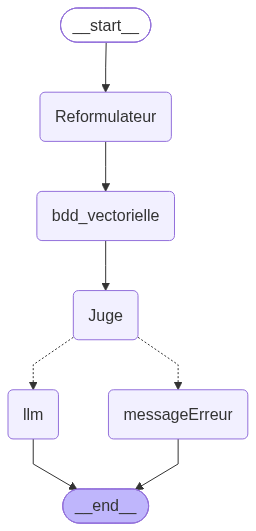

In [172]:
# toolnode = ToolNode(tools=tools)

graph = StateGraph(AgentState)
graph.add_node("llm",chatLLM)
graph.add_node("Reformulateur",MultiQuery)
graph.add_node("Juge",grade_documents)
graph.add_node("bdd_vectorielle",retriever)
graph.add_node("messageErreur",messageErreur)

graph.add_edge(START,"Reformulateur")
graph.add_edge("Reformulateur","bdd_vectorielle")
graph.add_edge("bdd_vectorielle","Juge")
graph.add_conditional_edges(
    "Juge",
    decide_to_generate,
    {
        "messageErreur":"messageErreur",
        "llm":"llm"
    }
)
graph.add_edge("llm",END)
agent = graph.compile()

# Génère et affiche le schéma
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    # Si les dépendances graphiques (pyperclip/graphviz) manquent
    print("Erreur d'affichage image, installation requise : pip install grandalf")


#### Tests

In [ ]:
response = agent.invoke({"messages":[HumanMessage(content="Qui était Jules César")]})
print(response["messages"][-1].content)

multiQuery
retriever
['caedb991-4ad0-44f2-8fa0-72faff45b862', 'e064dde3-cc8d-4772-9c64-0cbe7f99cdfc', '1be780c0-839f-408c-926c-33db0757e61f', '547d4d22-5be0-4db7-9b5c-f9ee0af80a7f']
Juge executé
reponse : yes
reponse : yes
reponse : yes
reponse : yes
chatLLM
[" : Histoire de la France pendant la Seconde Guerre mondiale.\n Soldats allemands défilant devant l'Arc de Triomphe à Paris, 14 juin 1940. \nAprès avoir déclaré la guerre le 3 septembre à l'Allemagne à la suite de son entrée en Pologne, la France tente avec le Royaume-Uni de secourir la Norvège victime d'un même assaut allemand ; sans succès probant. Cette « drôle de guerre » où il ne se passe pas grand-chose sur le front prend fin le 10 mai 1940 avec une offensive éclair (blitzkrieg) de l'Axe qui conquiert la France (directement la partie nord) en six semaines. Pourtant, Philippe Pétain avait fait construire la ligne Maginot le long de la frontière franco-allemande (il aurait voulu la construire également le long de la frontière 

In [175]:
response = agent.invoke({"messages":[HumanMessage(content="Que font 5 * 5?")]})
print(response["messages"][-1].content)

multiQuery
retriever
['100720f1-dc21-431a-b828-15dd59e1d2ee', '4c22658d-8fac-44d3-9f9a-cd0ddd8aebcb', 'ce142379-eb49-4e58-b53a-6c8930174870', '8714fa99-184e-4dab-8847-d5d0f84c7b70']
Juge executé
reponse : no
reponse : no
reponse : no
reponse : no
Je suis un assistant historien, je ne peux pas répondre à votre question
